## EDA — Military Drones Images

In [31]:
import yaml 
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import logging

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm 
from collections import Counter
import cv2 


sns.set(style="whitegrid")

In [32]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [33]:
class YOLODataset(Dataset):
    """
    Arguments:
        img_dir (str): Way to directory with images (example: 'train/images').
        label_dir (str): Way to directory with labels (example 'train/labels').
        transform (callable, optional): Transformations for an image (example: augmentations).
    """
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.transform = transform

        self.image_files = sorted([
            f for f in self.img_dir.iterdir() 
            if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png']
        ])
        
        self.valid_files = []
        for img_file in self.image_files:
            label_file = self.label_dir / (img_file.stem + '.txt')
            if label_file.exists():
                self.valid_files.append(img_file)
            else:
                logger.warning(f"No lable file for: {img_file.name}")

        logger.info(f"Found {len(self.valid_files)} valid pairs image/lable.")

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        img_path = self.valid_files[idx]
        image = Image.open(img_path).convert("RGB")
        img_width, img_height = image.size

        label_path = self.label_dir / (img_path.stem + '.txt')
        boxes = [] 
        
        try:
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        boxes.append([float(p) for p in parts])
                    elif len(parts) > 5:
                         logger.warning(f"Lable format is not 5-digit YOLO at {label_path.name}")
                         class_id = float(parts[0])
                    
            if not boxes:
                boxes = np.empty((0, 5), dtype=np.float32)
            else:
                boxes = np.array(boxes, dtype=np.float32)

        except Exception as e:
            logger.error(f"Error at the lable file reading {label_path}: {e}")
            boxes = np.empty((0, 5), dtype=np.float32) 
            
        target = {}
        target["boxes"] = boxes 
        target["image_id"] = idx
        target["image_path"] = str(img_path)
        target["original_size"] = (img_width, img_height)

        if self.transform:
            image = self.transform(image) 

        return image, target

In [34]:
ROOT_DIR = Path('data') 

yaml_path = ROOT_DIR / 'data.yaml'
try:
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    
    CLASS_NAMES = data_config['names']
    NUM_CLASSES = data_config['nc']
    
    print(f"Dataset is loaded. Number of classes: {NUM_CLASSES}")
    print(f"Classes names: {CLASS_NAMES}")
    
except Exception as e:
    print(f"An error by reading data.yaml: {e}")

Dataset is loaded. Number of classes: 11
Classes names: ['-', 'BBM', 'BMP', 'BTR', 'CAY', 'MTLB', 'Shishiga', 'buhanka', 'soldier', 'tank', 'truck']


In [35]:
def collect_eda_stats(dataset_root, split='train'):
    """Detailed statistics from dataset."""
    
    img_dir = dataset_root / split / 'images'
    label_dir = dataset_root / split / 'labels'
    
    dataset = YOLODataset(img_dir=img_dir, label_dir=label_dir)
    
    records = [] 
    
    print(f"Collecting statistics for: '{split}'... ")
    for i in tqdm(range(len(dataset))):
        try:
            image, target = dataset[i] 
            
            img_width, img_height = target["original_size"]
            aspect_ratio = img_width / img_height
            
            num_objects = len(target["boxes"])
            
            img_record = {                              #image info
                "split": split,
                "image_id": target["image_id"],
                "image_path": target["image_path"],
                "width": img_width,
                "height": img_height,
                "aspect_ratio": aspect_ratio,
                "num_objects": num_objects,
                "is_empty": num_objects == 0 
            }
            
            if num_objects == 0:
                records.append(img_record)
                continue

            for box in target["boxes"]:
                class_id, x_c, y_c, w, h = box
                
                box_record = {
                    **img_record, 
                    "class_id": int(class_id),
                    "class_name": CLASS_NAMES[int(class_id)],
                    "x_center_norm": x_c,
                    "y_center_norm": y_c,
                    "width_norm": w,
                    "height_norm": h,
                    "area_norm": w * h, 
                    
                    "box_width_abs": w * img_width,
                    "box_height_abs": h * img_height,
                    "box_area_abs": (w * img_width) * (h * img_height)
                }
                records.append(box_record)
                
        except Exception as e:
            logger.error(f"Index processing error {i} у '{split}': {e}")

    return pd.DataFrame(records)

In [36]:
df_train = collect_eda_stats(ROOT_DIR, 'train')
df_valid = collect_eda_stats(ROOT_DIR, 'valid')
df_test = collect_eda_stats(ROOT_DIR, 'test')

df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)

print("All statistics collected.")
print(df_all.info())

INFO:__main__:Found 5792 valid pairs image/lable.


100%|██████████| 5792/5792 [00:54<00:00, 106.07it/s]
INFO:__main__:Found 389 valid pairs image/lable.


100%|██████████| 389/389 [00:03<00:00, 104.56it/s]
INFO:__main__:Found 201 valid pairs image/lable.


100%|██████████| 201/201 [00:01<00:00, 108.98it/s]

All statistics collected.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8457 entries, 0 to 8456
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   split           8457 non-null   object 
 1   image_id        8457 non-null   int64  
 2   image_path      8457 non-null   object 
 3   width           8457 non-null   int64  
 4   height          8457 non-null   int64  
 5   aspect_ratio    8457 non-null   float64
 6   num_objects     8457 non-null   int64  
 7   is_empty        8457 non-null   bool   
 8   class_id        8456 non-null   float64
 9   class_name      8456 non-null   object 
 10  x_center_norm   8456 non-null   float64
 11  y_center_norm   8456 non-null   float64
 12  width_norm      8456 non-null   float64
 13  height_norm     8456 non-null   float64
 14  area_norm       8456 non-null   float64
 15  box_width_abs   8456 non-null   float64
 16  box_height_abs  8456 non-null   float64
 17  box_are

In [37]:
print("Overall statistics:")
print(f"Images (with labels) in total: {df_all['image_path'].nunique()}")
print(f"Objects (annotations) in total: {len(df_all[df_all['num_objects'] > 0])}")
print("-" * 30)
print("Distribution by sets (unique image quantity):")
print(df_all.groupby('split')['image_path'].nunique())

Overall statistics:
Images (with labels) in total: 6382
Objects (annotations) in total: 8456
------------------------------
Distribution by sets (unique image quantity):
split
test      201
train    5792
valid     389
Name: image_path, dtype: int64


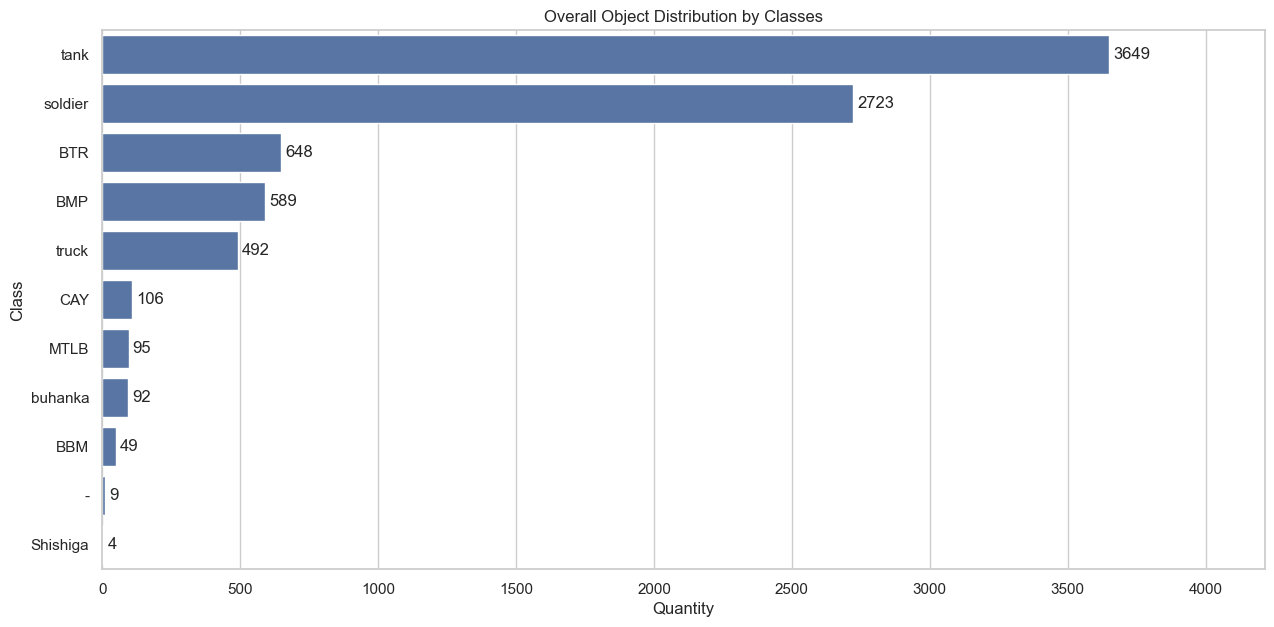

In [38]:
plt.figure(figsize=(15, 7))

ax = sns.countplot(
    data=df_all[df_all['class_name'].notna()], 
    y='class_name', 
    order=df_all['class_name'].value_counts().index
)

plt.title('Overall Object Distribution by Classes')
plt.xlabel('Quantity')
plt.ylabel('Class')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
    
current_xlim = ax.get_xlim()
ax.set_xlim(right=current_xlim[1] * 1.1) 

plt.show()

- This "overall" view confirms that the severe class imbalance seen in the train set is a characteristic of the entire dataset.

- The data is heavily skewed towards tank (3649) and soldier (2723). Meanwhile, classes like Shishiga (4), BBM (49), and buhanka (92) are critically underrepresented across all splits.

- The scarcity of rare classes will make it very difficult to reliably evaluate the model's performance on them. For instance, with only 4 Shishiga instances in total, there may be only one (or zero) in the test set.

- The problematic "-" class (9 instances) is present, reinforcing the need for data cleaning.

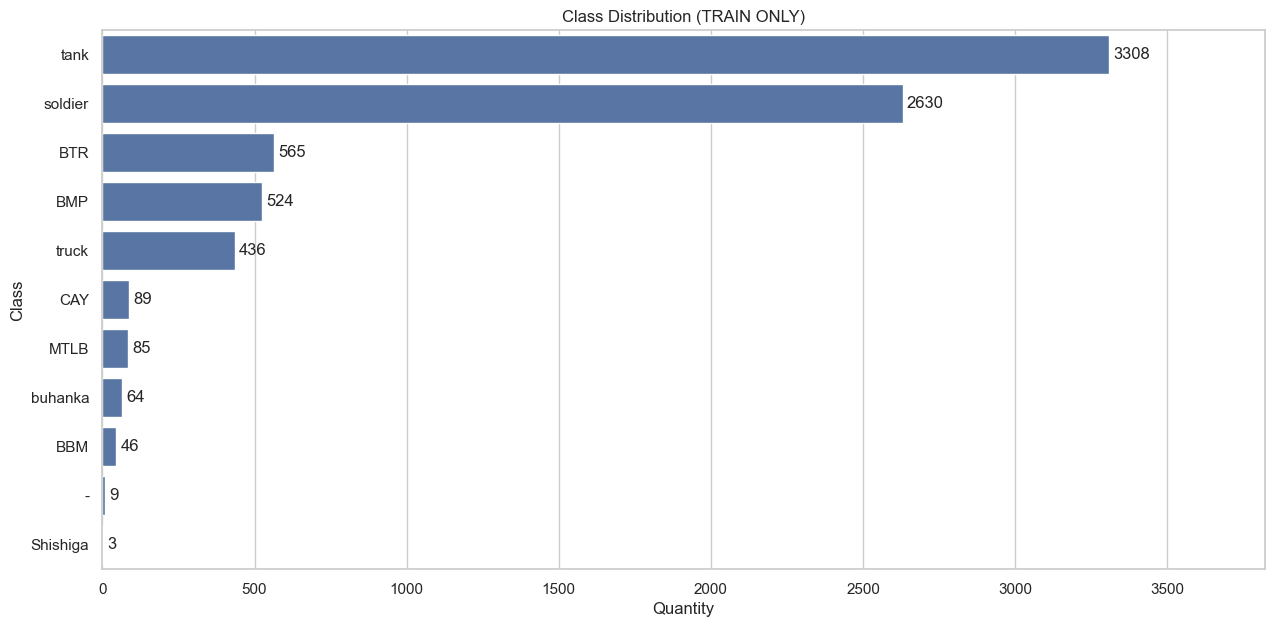

In [39]:
plt.figure(figsize=(15, 7))

ax = sns.countplot(
    data=df_train[df_train['class_name'].notna()], 
    y='class_name', 
    order=df_train['class_name'].value_counts().index
)

plt.title('Class Distribution (TRAIN ONLY)')
plt.xlabel('Quantity')
plt.ylabel('Class')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

current_xlim = ax.get_xlim()
ax.set_xlim(right=current_xlim[1] * 1.1) 

plt.show()

- The training dataset is extremely imbalanced.

- The model's training will be overwhelmingly dominated by two classes: tank (3308) and soldier (2630).

- There is a critical shortage of data for "long-tail" classes. Shishiga (3), BBM (46), buhanka (64), and others are severely underrepresented.

- The model will be highly biased towards tank and soldier. It will perform very poorly on rare classes unless a re-sampling strategy (like oversampling) or a weighted loss function is used.

- The class "-" (9 instances) is almost certainly a data entry or labeling error that should be cleaned.

Images without objects (negatives): 1


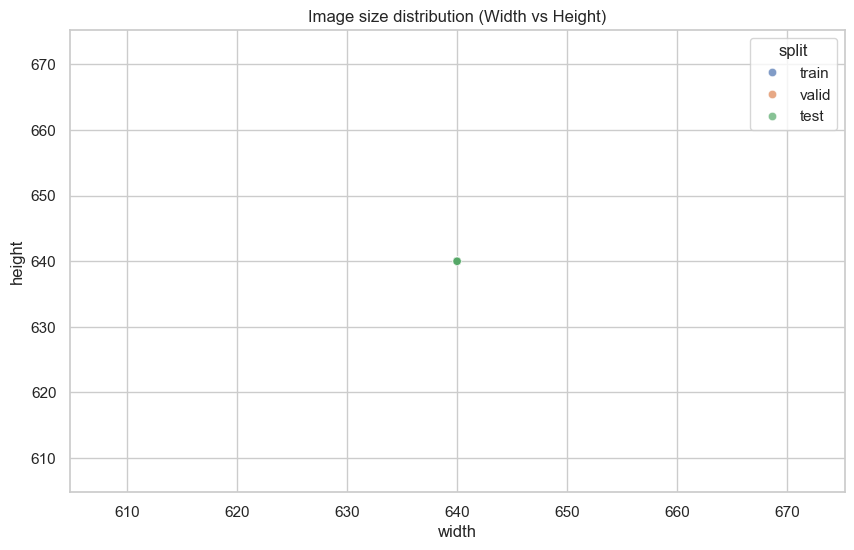

In [40]:
df_images = df_all.drop_duplicates(subset=['image_path'])

print(f"Images without objects (negatives): {df_images['is_empty'].sum()}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_images, x='width', y='height', hue='split', alpha=0.7)
plt.title('Image size distribution (Width vs Height)')
plt.show()

- The dataset is extremely consistent. All images across the train, valid, and test splits have the exact same dimensions.

- Every image is 640x640 pixels.

- This is ideal for modeling. It completely eliminates the need for resizing, padding, or aspect ratio handling (letterboxing), simplifying the entire preprocessing pipeline.

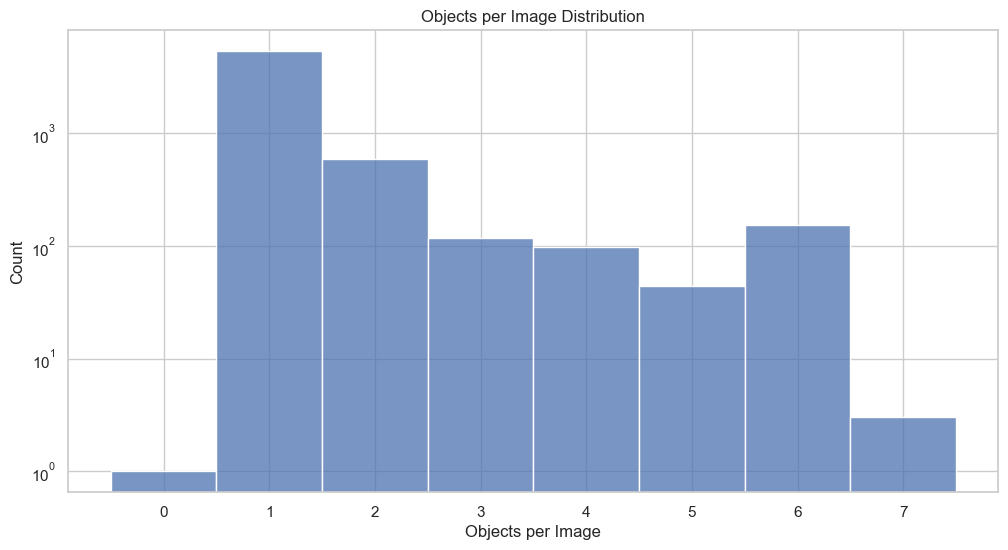

In [41]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_images, x='num_objects', bins=max(df_images['num_objects']), discrete=True)
plt.title('Objects per Image Distribution')
plt.xlabel('Objects per Image')
plt.yscale('log') 
plt.show()

- The dataset is dominated by images with a low number of objects. The most frequent case by far is a single object per image (over 1,000 instances), followed by two objects.

- There are almost no "empty" images (0 objects). This is a critical insight: the model will not learn from background-only examples, which might lead to a higher rate of false positives when deployed.

- Interestingly, there is a small, unexpected spike at 6 objects per image, which is more common than images with 3, 4, or 5 objects. This might point to a specific but recurring scene type in the dataset.

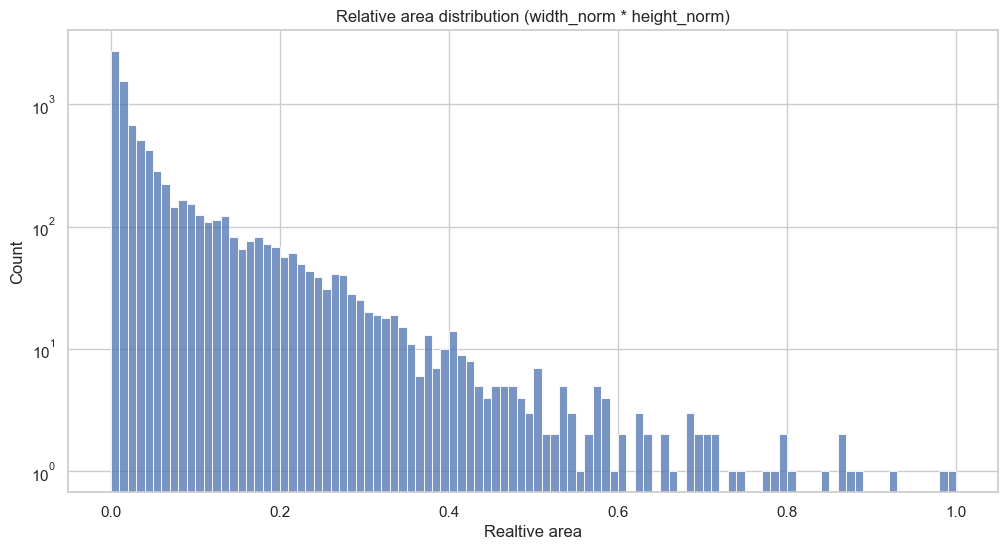

In [42]:
plt.figure(figsize=(12, 6))
sns.histplot(df_all['area_norm'], bins=100, kde=False)
plt.title('Relative area distribution (width_norm * height_norm)')
plt.xlabel('Realtive area')
plt.yscale('log')
plt.show()

- The dataset is overwhelmingly dominated by small objects.

- The distribution is extremely right-skewed. The vast majority of bounding boxes have a relative area very close to 0 (occupying a tiny fraction of the total image area).

- The logarithmic y-axis confirms this is not a gentle slope; the number of objects drops exponentially as their relative size increases. The first bin (smallest objects) has over 1,000 instances, while medium-to-large objects (e.g., area > 0.4) are rare.

- This is a classic small object detection problem. The model's primary challenge will be to find these small items, which may require high-resolution inputs or specialized model architectures (like FPNs with more levels).

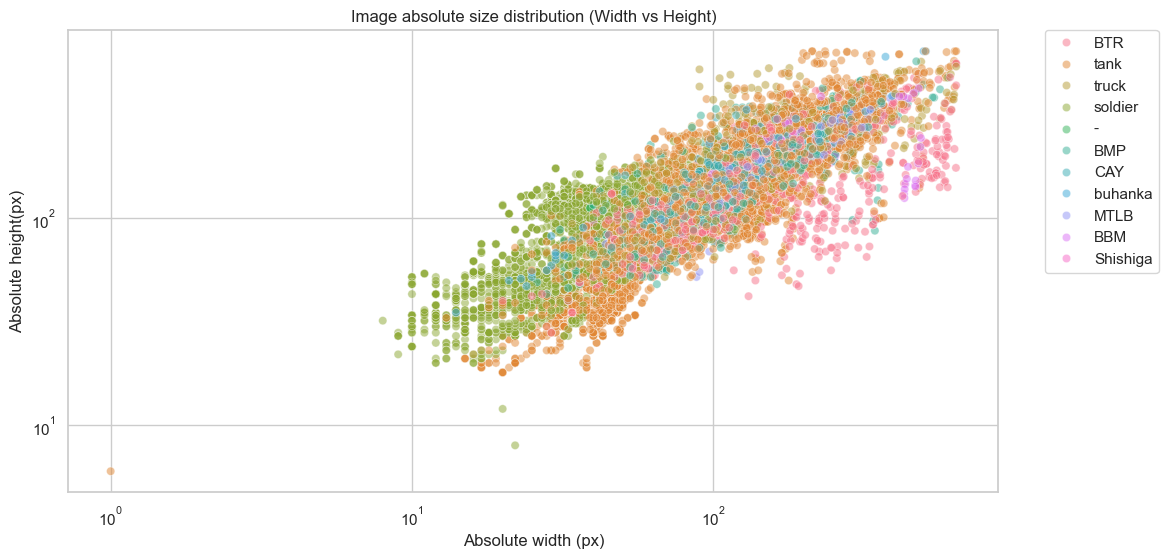

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_all, 
                x='box_width_abs', 
                y='box_height_abs', 
                hue='class_name', 
                alpha=0.5)
plt.title('Image absolute size distribution (Width vs Height)')
plt.xlabel('Absolute width (px)')
plt.ylabel('Absolute height(px)')
plt.xscale('log')
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

- The plot (using a log-log scale) confirms that the dataset contains objects of vastly different sizes, from very small (under 20 pixels) to quite large (over 200 pixels).

- There is a strong relationship between an object's class and its size.

    - The soldier class (light green) is distinctly clustered in the lower-left, indicating they are almost always the smallest objects in the dataset (mostly 10-50 pixels).

    - Vehicles like BTR, tank, and truck are distributed across the mid-to-large size range.

- This presents a significant multi-scale detection challenge. The model must be configured to be sensitive to both very small objects (soldiers) and large objects (vehicles) simultaneously.

- There is one extreme outlier (around width=1, height=7) that is almost certainly an annotation error.

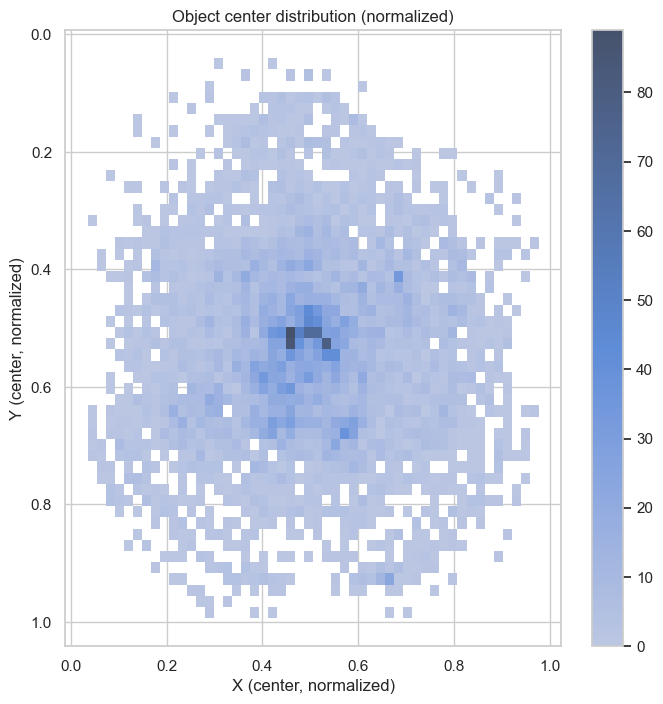

In [44]:
plt.figure(figsize=(8, 8))
sns.histplot(data=df_all, x='x_center_norm', y='y_center_norm', bins=50, cbar=True)
plt.title('Object center distribution (normalized)')
plt.xlabel('X (center, normalized)')
plt.ylabel('Y (center, normalized)')
plt.gca().invert_yaxis() 
plt.show()

- The plot reveals a very strong spatial bias. The vast majority of object centers are heavily concentrated in the exact middle of the image (around the X=0.5, Y=0.5 coordinates).

- There is a significant lack of objects near the edges, and the corners of the images are almost completely empty.

- A model trained on this data might learn to only look for objects in the center, potentially missing objects that appear near the edges in real-world or test-set scenarios.

In [45]:
def visualize_sample(image_path, target, class_names):
    """Draws image with annotations."""
    
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    h, w, _ = image.shape
    
    boxes = target.get("boxes", [])
    
    if len(boxes) == 0:
        print(f"Image {image_path.name} has no objects.")
    
    for box in boxes:
        class_id, x_c, y_c, w_norm, h_norm = box
        
        box_w = w_norm * w
        box_h = h_norm * h
        x_min = int((x_c * w) - (box_w / 2))
        y_min = int((y_c * h) - (box_h / 2))
        x_max = int(x_min + box_w)
        y_max = int(y_min + box_h)
        
        color = (255, 0, 0) 
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, 2)
        
        label = class_names[int(class_id)]
        cv2.putText(image, label, (x_min, y_min - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"{image_path.name} | Objects: {len(boxes)}")
    plt.axis('off')
    plt.show()

INFO:__main__:Found 5792 valid pairs image/lable.


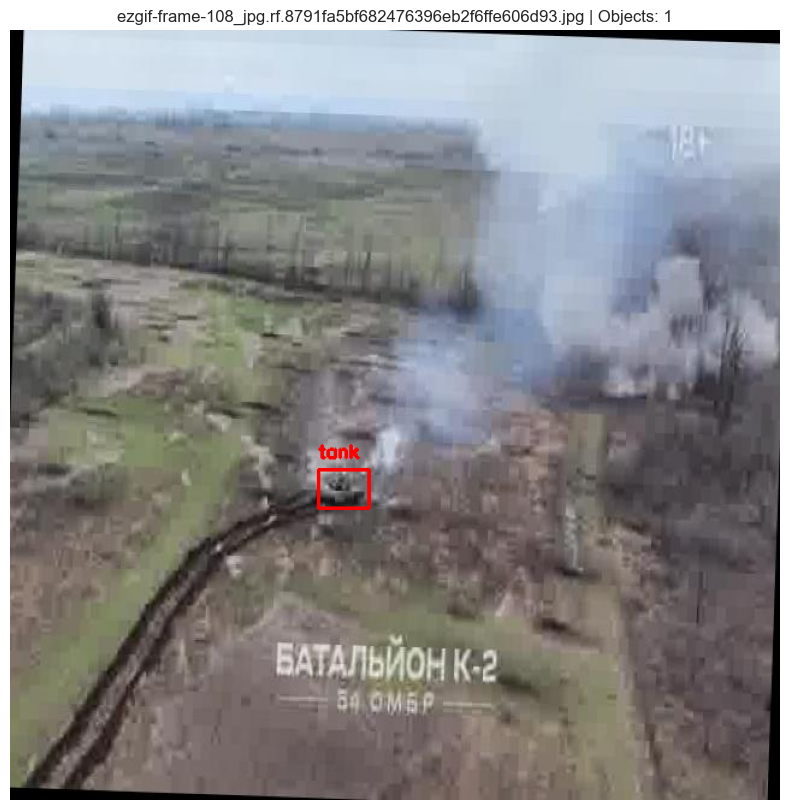

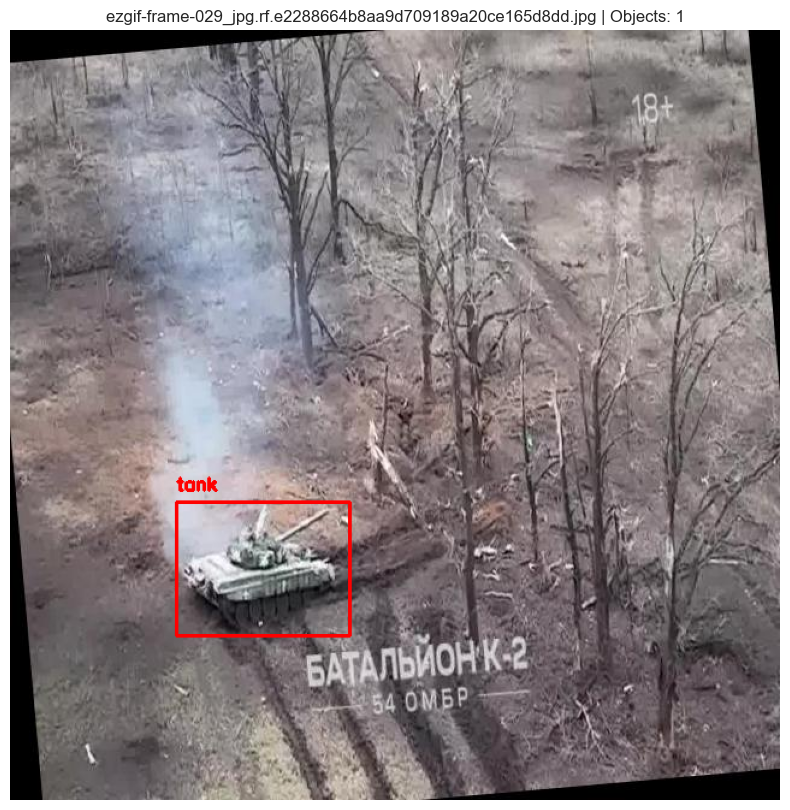

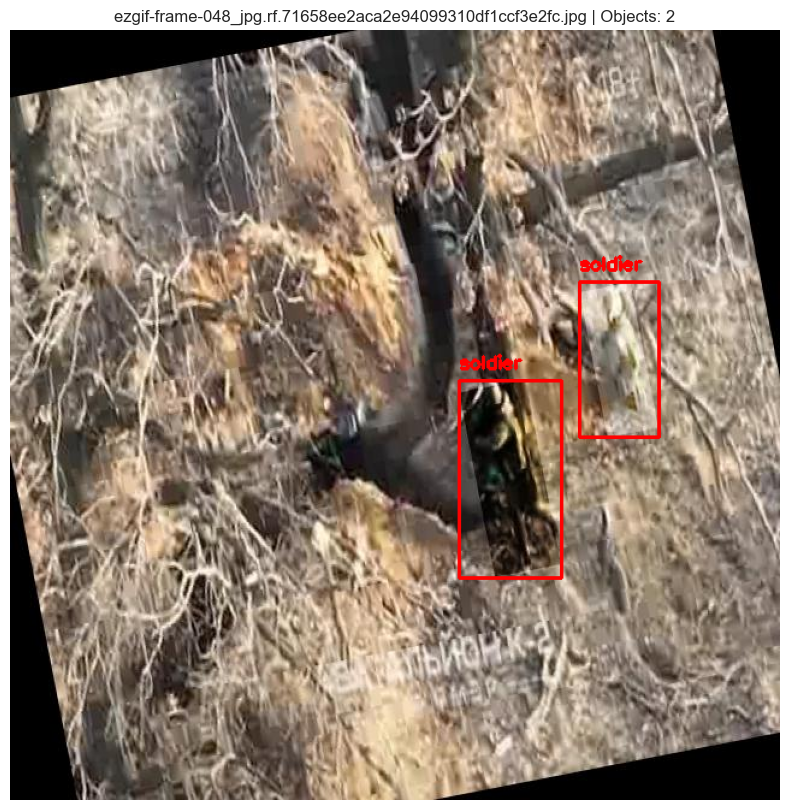

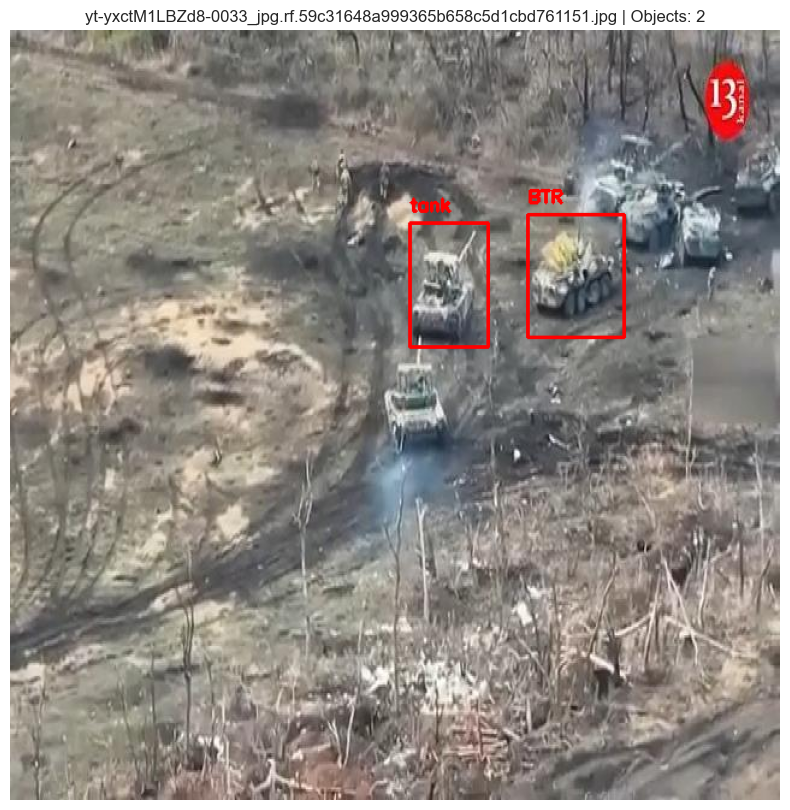

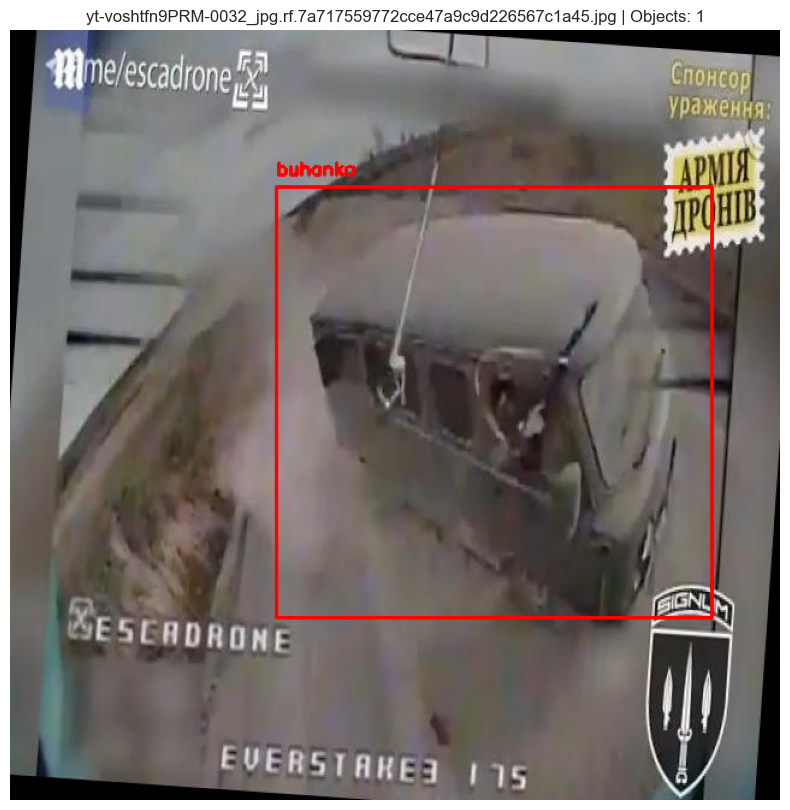

In [46]:
train_dataset = YOLODataset(ROOT_DIR / 'train' / 'images', ROOT_DIR / 'train' / 'labels')

for _ in range(5):
    idx = np.random.randint(0, len(train_dataset))
    _, target = train_dataset[idx] 
    visualize_sample(Path(target['image_path']), target, CLASS_NAMES)

Based on the exploratory data analysis, the dataset reveals several critical characteristics that will directly influence model development. The dataset's primary strength is its perfect consistency in image structure; all images across the train, validation, and test splits are of a uniform 640x640 pixel dimension. This significantly simplifies the preprocessing pipeline by eliminating any need for resizing, padding, or aspect ratio handling.

However, this structural benefit is offset by three severe challenges. First is a critical class imbalance. The data is overwhelmingly dominated by the tank and soldier classes, while a "long-tail" of other classes, such as Shishiga and BBM, are so rare as to be almost statistically insignificant. This imbalance is guaranteed to create a model heavily biased towards the dominant classes.

Second, this is fundamentally a small object detection problem. The relative area plot shows a massive skew towards zero, indicating that most objects occupy a tiny fraction of the image. This is corroborated by the absolute size plot, which identifies the soldier class as consistently being very small (10-50 pixels).

Third, the dataset contains significant spatial and quantitative biases. Objects are not distributed naturally; instead, they are heavily concentrated in the exact center of the frame, with almost no objects appearing near the edges. Furthermore, the dataset almost completely lacks "negative" or "empty" images (those with zero objects), which will likely lead to a high rate of false positives as the model has not been trained on background-only scenes. In summary, while the data is structurally simple, its severe class imbalance, dominance of small objects, and critical spatial biases present significant challenges for training a robust and generalizable model.